In [1]:
# @title Running in Colab

from IPython.display import HTML, Javascript, display

display(
    HTML(
        """<a href="https://colab.research.google.com/github/evan-lloyd/mechinterp-experiments/blob/main/tiny_stories_sae/feature_interaction_demo.ipynb" target="_blank" id="colab-button">
            Run this notebook in Google Colab
        </a>"""
    )
)
display(
    Javascript("""
        setTimeout(() => {
            if(typeof google.colab != "undefined") {
                document.querySelector("#colab-button").remove()
            }
        }, 0);
        """)
)

<IPython.core.display.Javascript object>

# Initialize notebook environment

In [2]:
import os

# If we're running in Colab, we need to clone the non-notebook source from git.
if os.getenv("COLAB_RELEASE_TAG") and not os.path.isdir(
    "/content/mechinterp-experiments"
):
    ip = get_ipython()  #  pyright: ignore[reportUndefinedVariable]
    ip.run_cell_magic(
        "bash",
        "",
        """
    git clone --filter=blob:none --no-checkout https://github.com/evan-lloyd/mechinterp-experiments.git
    cd mechinterp-experiments
    git sparse-checkout init --no-cone
    echo "/tiny_stories_sae" > .git/info/sparse-checkout
    git checkout
  """,
    )
    ip.run_line_magic("cd", "mechinterp-experiments/tiny_stories_sae")
else:
    print("Already cloned source, or not running in Colab.")

# Nice for dev, but not needed for Colab.
try:
    # This uses a library called jurigged to hot-reload code when it is changed.
    # For reasons I've never been able to figure out, the IPython %autoreload magic
    # completely fails to work with the kind of structure I use in this notebook.
    import tiny_stories_sae._autoreload
except Exception:
    pass

Already cloned source, or not running in Colab.


In [3]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 16
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 8
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 8

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M")
training_dataset = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
validation_dataset = load_dataset(
    "roneneldan/TinyStories", split="validation", streaming=True
)
model = AutoModelForCausalLM.from_pretrained("roneneldan/TinyStories-33M").to(
    TRAINING_DEVICE
)

print(model)

GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(2048, 768)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-3): 4 x GPTNeoBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=False)
            (q_proj): Linear(in_features=768, out_features=768, bias=False)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (c_proj): Linear(in_feat

In [4]:
# Caches model activations to these directories; modify if necessary, or set to None to disable.
# These take up ~16GB and ~1.5GB respectively, but will save a fair bit of time when running
# the notebook, since they can be re-used across all methods we're comparing.
# Skip caching if CUDA is available, as at least on the cloud hardware I was using it was actually
# faster to just re-run the model than to load from disk! (Possibly my caching implementation is just bad.)
TRAINING_CACHE_DIR = None if torch.cuda.is_available() else ".training_cache"
VALIDATION_CACHE_DIR = None if torch.cuda.is_available() else ".validation_cache"
NUM_TRAINING_TOKENS = int(1e7) if torch.cuda.is_available() else int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e6) if torch.cuda.is_available() else int(1e5)
D_MODEL = model.config.hidden_size
D_SAE = D_MODEL * 4
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

# Train SAEs

In [5]:
from itertools import product

import numpy as np

from tiny_stories_sae.sae import (
    SAE,
    DecoderConfig,
    EncoderConfig,
    InteractionEncoderConfig,
    ReluActivationFunctionConfig,
    SAEConfig,
    TopKActivationFunctionConfig,
)
from tiny_stories_sae.training import TrainingConfig, TrainingMethod, fine_tune, train
from tiny_stories_sae.validation import run_validations


def SAE_SPECS():
    return product(TrainingMethod, (False, True))


empty_saes = {
    (method, use_interaction): {
        layer: SAE(
            SAEConfig(
                d_model=D_MODEL,
                d_sae=D_SAE,
                device=TRAINING_DEVICE,
                encoder=EncoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                    activation_function=TopKActivationFunctionConfig(k=TOPK),
                )
                if not use_interaction
                else InteractionEncoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                    activation_function=TopKActivationFunctionConfig(k=TOPK),
                    n_interaction_iterations=1,
                ),
                decoder=DecoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                ),
            )
        )
        for layer in range(model.config.num_layers)
    }
    for method, use_interaction in SAE_SPECS()
}


def linear_decay_during_finetune(frac_trained: float):
    if frac_trained < (1 - FINETUNE_FRACTION):
        return 1.0
    return 1.0 - (frac_trained - (1 - FINETUNE_FRACTION)) / FINETUNE_FRACTION


training_config = {
    (method, use_interaction): TrainingConfig(
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        training_batch_size=TRAINING_BATCH_SIZE,
        num_train_tokens=NUM_TRAINING_TOKENS,
        eval_interval=EVAL_INTERVAL,
        train_layers=list(range(model.config.num_layers)),
        lr=1e-3,
        interaction_lr=1e-3,
        lr_schedule=linear_decay_during_finetune,  # per Karvonen (2025)
        downstream_reconstruction_weight=1.0,
        reconstruction_weight=1.0,
        balance_reconstruction_losses=True,
        method=method,
        finetune_fraction=FINETUNE_FRACTION
        if method in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned)
        else None,
    )
    for method, use_interaction in SAE_SPECS()
}

training_results = {}
validation_results = {}

In [6]:
import os

from tiny_stories_sae.activation_cache import build_cache

if TRAINING_CACHE_DIR and (
    not os.path.exists(TRAINING_CACHE_DIR) or not os.listdir(TRAINING_CACHE_DIR)
):
    build_cache(
        TRAINING_CACHE_DIR,
        model,
        tokenizer,
        training_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_TRAINING_TOKENS,
    )

if VALIDATION_CACHE_DIR and (
    not os.path.exists(VALIDATION_CACHE_DIR) or not os.listdir(VALIDATION_CACHE_DIR)
):
    build_cache(
        VALIDATION_CACHE_DIR,
        model,
        tokenizer,
        validation_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_VALIDATION_TOKENS,
    )

In [28]:
for spec in SAE_SPECS():
    if spec[1] or spec[0] not in (TrainingMethod.standard, TrainingMethod.next_layer):
        continue
    # We finetune these from checkpoints of other methods
    if spec[0] in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned):
        continue
    print(f"Training {spec[0].value}, use_interaction={spec[1]}")
    training_results[spec] = train(
        model,
        tokenizer,
        empty_saes[spec],
        training_dataset,
        training_config[spec],
        cache_dir=TRAINING_CACHE_DIR,
        checkpoints_at=[int((1.0 - FINETUNE_FRACTION) * NUM_TRAINING_TOKENS)]
        if spec[0] in (TrainingMethod.standard, TrainingMethod.next_layer)
        else None,
    )
    validation_results[spec] = run_validations(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        cache_dir=VALIDATION_CACHE_DIR,
    )
    print(
        f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })"
    )
    print(
        f"geom mean kl={ {k: np.exp(np.mean(np.log(v.kl[v.kl > 0]))).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })"
    )

Training Standard, use_interaction=False


Layer 3

  0%|          | 0/10000000 [00:00<?, ?it/s]

Layer 2

  0%|          | 0/10000000 [00:00<?, ?it/s]

...

  0%|          | 0/10000000 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/10000000 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

mean rre={0: 0.207600399851799, 1: 0.2873792052268982, 2: 0.3916989266872406, 3: 0.6202793717384338})
geom mean kl={4: 0.13317495584487915})


In [35]:
for spec in SAE_SPECS():
    if spec[1] or spec[0] not in (TrainingMethod.finetuned,):
        continue
    if spec[0] not in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned):
        continue
    print(f"Training {spec[0].value}, use_interaction={spec[1]}")
    training_results[spec] = fine_tune(
        model,
        tokenizer,
        training_results[
            (
                TrainingMethod.standard
                if spec[0] == TrainingMethod.finetuned
                else TrainingMethod.next_layer,
                spec[1],
            )
        ],
        0,
        training_dataset,
        training_config[spec],
        cache_dir=TRAINING_CACHE_DIR,
    )
    validation_results[spec] = run_validations(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        cache_dir=VALIDATION_CACHE_DIR,
    )
    print(
        f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })"
    )
    print(
        f"geom mean kl={ {k: np.exp(np.mean(np.log(v.kl[v.kl > 0]))).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })"
    )


Training KL Fine-tuning, use_interaction=False


Layer 3

  0%|          | 0/994735 [00:00<?, ?it/s]

Layer 2

  0%|          | 0/994735 [00:00<?, ?it/s]

...

  0%|          | 0/994735 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/994735 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

mean rre={0: 0.20462395250797272, 1: 0.2938932180404663, 2: 0.4021186828613281, 3: 0.6128812432289124})
geom mean kl={4: 0.181915283203125})


In [36]:
# Print KL statistics as an HTML table
from tiny_stories_sae.ops import display_sortable_html_table

headers = ["Layer", "Method", "Interaction", "Geometric Mean KL", "GSD Lower", "GSD Upper"]
rows = []

methods = []
seen_methods = set()
for spec in validation_results:
    if spec[0] not in seen_methods:
        methods.append(spec[0])
method_labels = [m.value for m in methods]

for layer in [model.config.num_layers]:
    for method, method_label in zip(methods, method_labels):
        for has_interaction in [False, True]:
            spec = (method, has_interaction)
            if spec not in validation_results:
                continue

            interaction_label = "Yes" if has_interaction else "No"
            
            if layer in validation_results[spec].layer_results:
                kl_values = validation_results[spec].layer_results[layer].kl
                if kl_values is not None and len(kl_values) > 0:
                    kl_positive = kl_values[kl_values > 0]
                    if len(kl_positive) > 0:
                        log_kl = np.log(kl_positive)
                        log_mean = np.mean(log_kl)
                        log_std = np.std(log_kl)
                        gm = np.exp(log_mean)
                        gsd = np.exp(log_std)
                        gsd_lower = gm - gm / gsd
                        gsd_upper = gm * gsd - gm
                    else:
                        gm, gsd_lower, gsd_upper = 0, 0, 0
                else:
                    gm, gsd_lower, gsd_upper = 0, 0, 0
            else:
                gm, gsd_lower, gsd_upper = 0, 0, 0
            
            rows.append([layer, method_label, interaction_label, f"{gm:.6f}", f"{gsd_lower:.6f}", f"{gsd_upper:.6f}"])

display_sortable_html_table(headers, rows)

Layer ⇅,Method ⇅,Interaction ⇅,Geometric Mean KL ⇅,GSD Lower ⇅,GSD Upper ⇅
4,Standard,No,0.180203,0.169563,2.871815
4,End-to-end,No,0.146339,0.132766,1.431399
4,KL Fine-tuning,No,0.181915,0.163834,1.648302
4,Next Layer,No,0.133175,0.122695,1.559189
4,Next Layer + Fine-Tuning,No,0.125258,0.114977,1.400700


In [63]:
# Print final loss values as an HTML table
headers = ["Method", "Interaction", "Layer", "Final Total Loss"]
rows = []

metric_key = "total_loss"
for spec in training_results:
    method, has_interaction = spec
    method_label = method.value
    interaction_label = "Yes" if has_interaction else "No"

    train_result = training_results[spec]
    for layer in train_result.keys():
        # Get the last checkpoint's metrics
        checkpoints = train_result[layer]
        if checkpoints:
            last_checkpoint = checkpoints[-1]
            if metric_key not in last_checkpoint.step_metrics:
                mk = "raw_loss.reconstruction"
            else:
                mk = metric_key
            if (
                mk in last_checkpoint.step_metrics
                and len(last_checkpoint.step_metrics[mk]) > 0
            ):
                final_loss = last_checkpoint.step_metrics[mk][-1]
                rows.append(
                    [method_label, interaction_label, layer, f"{final_loss:.6f}"]
                )

display_sortable_html_table(headers, rows)

Method ⇅,Interaction ⇅,Layer ⇅,Final Total Loss ⇅
Standard,No,0,0.006709
Standard,No,1,0.020854
Standard,No,2,0.055410
Standard,No,3,0.149963
End-to-end,No,0,0.123970
End-to-end,No,1,0.152849
End-to-end,No,2,0.145552
End-to-end,No,3,189.660583
KL Fine-tuning,No,0,0.008751
KL Fine-tuning,No,1,0.025962


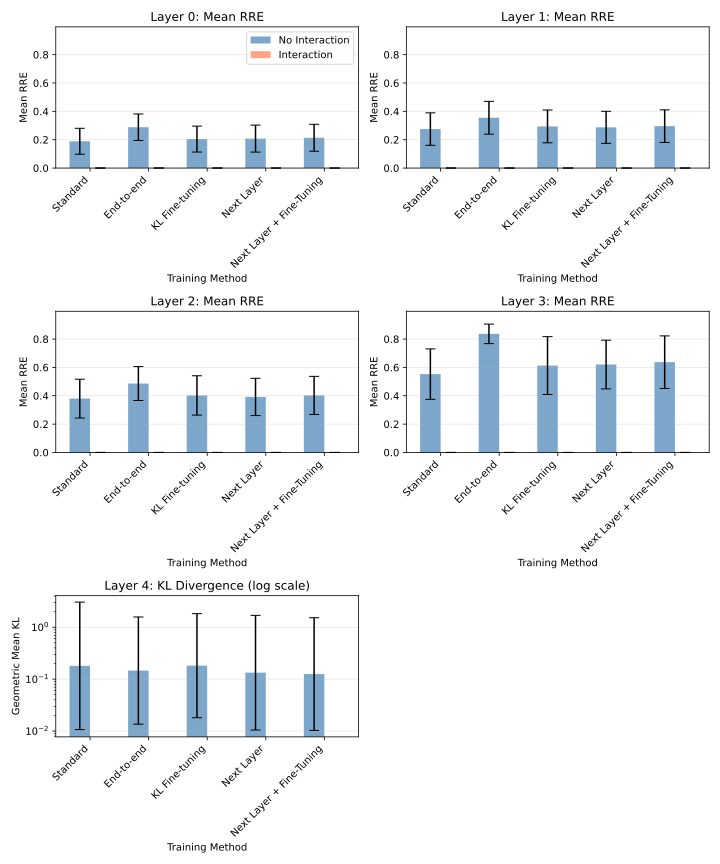

In [37]:
import matplotlib.pyplot as plt
import numpy as np

from tiny_stories_sae.ops import current_plot_to_svg

num_plots = model.config.num_layers + 1
num_cols = 2
num_rows = (num_plots + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten()

plot_idx = 0

# Group specs by method
methods = []
seen_methods = set()
for spec in validation_results:
    if spec[0] not in seen_methods:
        methods.append(spec[0])
        seen_methods.add(spec[0])

method_labels = [m.value for m in methods]
x = np.arange(len(methods))
bar_width = 0.35

colors = {'no_interaction': 'steelblue', 'interaction': 'coral'}

# Plot RRE bar charts for each layer
# First pass: compute global max for RRE across all layers
rre_max = 0
for layer in range(model.config.num_layers):
    for method in methods:
        for use_interaction in [False, True]:
            spec = (method, use_interaction)
            if spec in validation_results and layer in validation_results[spec].layer_results:
                rre_values = validation_results[spec].layer_results[layer].rre
                if rre_values is not None and len(rre_values) > 0:
                    rre_max = max(rre_max, np.mean(rre_values) + np.std(rre_values))

for layer in range(model.config.num_layers):
    ax = axes[plot_idx]
    means_no_int = []
    stds_no_int = []
    means_int = []
    stds_int = []
    
    for method in methods:
        # No interaction
        spec_no_int = (method, False)
        if spec_no_int in validation_results and layer in validation_results[spec_no_int].layer_results:
            rre_values = validation_results[spec_no_int].layer_results[layer].rre
            if rre_values is not None and len(rre_values) > 0:
                means_no_int.append(np.mean(rre_values))
                stds_no_int.append(np.std(rre_values))
            else:
                means_no_int.append(0)
                stds_no_int.append(0)
        else:
            means_no_int.append(0)
            stds_no_int.append(0)
        
        # With interaction
        spec_int = (method, True)
        if spec_int in validation_results and layer in validation_results[spec_int].layer_results:
            rre_values = validation_results[spec_int].layer_results[layer].rre
            if rre_values is not None and len(rre_values) > 0:
                means_int.append(np.mean(rre_values))
                stds_int.append(np.std(rre_values))
            else:
                means_int.append(0)
                stds_int.append(0)
        else:
            means_int.append(0)
            stds_int.append(0)
    
    ax.bar(x - bar_width/2, means_no_int, bar_width, yerr=stds_no_int, capsize=5, alpha=0.7, 
           color=colors['no_interaction'], label='No Interaction')
    ax.bar(x + bar_width/2, means_int, bar_width, yerr=stds_int, capsize=5, alpha=0.7,
           color=colors['interaction'], label='Interaction')
    ax.set_xlabel("Training Method")
    ax.set_ylabel("Mean RRE")
    ax.set_title(f"Layer {layer}: Mean RRE")
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, rotation=45, ha='right')
    ax.set_ylim(0, rre_max * 1.1)
    ax.grid(True, alpha=0.3, axis='y')
    if plot_idx == 0:
        ax.legend()
    plot_idx += 1

# Plot KL bar charts in log-space for each layer that has it
for layer in [model.config.num_layers]:
    ax = axes[plot_idx]
    gmeans_no_int = []
    gstd_lower_no_int = []
    gstd_upper_no_int = []
    gmeans_int = []
    gstd_lower_int = []
    gstd_upper_int = []
    
    for method in methods:
        # No interaction
        spec_no_int = (method, False)
        if spec_no_int in validation_results and layer in validation_results[spec_no_int].layer_results:
            kl_values = validation_results[spec_no_int].layer_results[layer].kl
            if kl_values is not None and len(kl_values) > 0:
                kl_positive = kl_values[kl_values > 0]
                if len(kl_positive) > 0:
                    log_kl = np.log(kl_positive)
                    log_mean = np.mean(log_kl)
                    log_std = np.std(log_kl)
                    gm = np.exp(log_mean)
                    gmeans_no_int.append(gm)
                    gsd = np.exp(log_std)
                    gstd_lower_no_int.append(gm - gm / gsd)
                    gstd_upper_no_int.append(gm * gsd - gm)
                else:
                    gmeans_no_int.append(0)
                    gstd_lower_no_int.append(0)
                    gstd_upper_no_int.append(0)
            else:
                gmeans_no_int.append(0)
                gstd_lower_no_int.append(0)
                gstd_upper_no_int.append(0)
        else:
            gmeans_no_int.append(0)
            gstd_lower_no_int.append(0)
            gstd_upper_no_int.append(0)
        
        # With interaction
        spec_int = (method, True)
        if spec_int in validation_results and layer in validation_results[spec_int].layer_results:
            kl_values = validation_results[spec_int].layer_results[layer].kl
            if kl_values is not None and len(kl_values) > 0:
                kl_positive = kl_values[kl_values > 0]
                if len(kl_positive) > 0:
                    log_kl = np.log(kl_positive)
                    log_mean = np.mean(log_kl)
                    log_std = np.std(log_kl)
                    gm = np.exp(log_mean)
                    gmeans_int.append(gm)
                    gsd = np.exp(log_std)
                    gstd_lower_int.append(gm - gm / gsd)
                    gstd_upper_int.append(gm * gsd - gm)
                else:
                    gmeans_int.append(0)
                    gstd_lower_int.append(0)
                    gstd_upper_int.append(0)
            else:
                gmeans_int.append(0)
                gstd_lower_int.append(0)
                gstd_upper_int.append(0)
        else:
            gmeans_int.append(0)
            gstd_lower_int.append(0)
            gstd_upper_int.append(0)
    
    ax.bar(x - bar_width/2, gmeans_no_int, bar_width, yerr=[gstd_lower_no_int, gstd_upper_no_int], 
           capsize=5, alpha=0.7, color=colors['no_interaction'], label='No Interaction')
    ax.bar(x + bar_width/2, gmeans_int, bar_width, yerr=[gstd_lower_int, gstd_upper_int],
           capsize=5, alpha=0.7, color=colors['interaction'], label='Interaction')
    ax.set_yscale('log')
    ax.set_xlabel("Training Method")
    ax.set_ylabel("Geometric Mean KL")
    ax.set_title(f"Layer {layer}: KL Divergence (log scale)")
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    # ax.legend()
    plot_idx += 1

# Hide any unused axes
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
current_plot_to_svg()

In [38]:
# Print RRE statistics as an HTML table
from tiny_stories_sae.ops import display_sortable_html_table

headers = ["Layer", "Method", "Interaction", "Mean RRE", "Std RRE"]
rows = []

for layer in range(model.config.num_layers):
    for method, method_label in zip(methods, method_labels):
        for has_interaction in [False, True]:
            spec = (method, has_interaction)
            if spec not in validation_results:
                continue
            interaction_label = "Yes" if has_interaction else "No"
            
            if layer in validation_results[spec].layer_results:
                rre_values = validation_results[spec].layer_results[layer].rre
                if rre_values is not None and len(rre_values) > 0:
                    mean_rre = np.mean(rre_values)
                    std_rre = np.std(rre_values)
                else:
                    mean_rre, std_rre = 0, 0
            else:
                mean_rre, std_rre = 0, 0
            
            rows.append([layer, method_label, interaction_label, f"{mean_rre:.6f}", f"{std_rre:.6f}"])

display_sortable_html_table(headers, rows)

Layer ⇅,Method ⇅,Interaction ⇅,Mean RRE ⇅,Std RRE ⇅
0,Standard,No,0.188895,0.091447
0,End-to-end,No,0.288028,0.093345
0,KL Fine-tuning,No,0.204624,0.091430
0,Next Layer,No,0.207600,0.095264
0,Next Layer + Fine-Tuning,No,0.213641,0.095087
1,Standard,No,0.275140,0.114668
1,End-to-end,No,0.354788,0.115573
1,KL Fine-tuning,No,0.293893,0.115968
1,Next Layer,No,0.287379,0.113152
1,Next Layer + Fine-Tuning,No,0.295754,0.115085


In [39]:
from tiny_stories_sae.ops import save_training_result, ensure_directory

if SAVE_FINAL_RESULTS:
    ensure_directory(".checkpoints")
    ensure_directory(".checkpoints/feature_interaction_demo")
    for spec in training_results.keys():
        save_training_result(
            training_results[spec],
            f".checkpoints/feature_interaction_demo/{spec[0].name}{'_interaction' if spec[1] else ''}",
        )

In [56]:
from tiny_stories_sae.validation import run_single_layer_replacements

single_layer_validations = {}
for spec in validation_results.keys():
    print(spec)
    single_layer_validations[spec] = run_single_layer_replacements(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        cache_dir=VALIDATION_CACHE_DIR,
        #start_layer=2,
        #end_layer=3,
    )

(<TrainingMethod.standard: 'Standard'>, False)


Running SAE evals (layer 0):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 1):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 2):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 3):   0%|          | 0/1000000 [00:00<?, ?it/s]

...

(<TrainingMethod.next_layer_finetuned: 'Next Layer + Fine-Tuning'>, False)


Running SAE evals (layer 0):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 1):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 2):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 3):   0%|          | 0/1000000 [00:00<?, ?it/s]

In [57]:
# Print KL statistics as an HTML table
from tiny_stories_sae.ops import display_sortable_html_table

headers = ["Layer", "Method", "Interaction", "Geometric Mean KL", "GSD Lower", "GSD Upper"]
rows = []

methods = []
seen_methods = set()
for spec in single_layer_validations:
    if spec[0] not in seen_methods:
        methods.append(spec[0])
method_labels = [m.value for m in methods]

for layer in range(model.config.num_layers):
    for method, method_label in zip(methods, method_labels):
        for has_interaction in [False, True]:
            spec = (method, has_interaction)
            if spec not in single_layer_validations or layer not in single_layer_validations[spec].layer_results:
                continue

            interaction_label = "Yes" if has_interaction else "No"
            
            if layer in single_layer_validations[spec].layer_results:
                kl_values = single_layer_validations[spec].layer_results[layer].kl
                if kl_values is not None and len(kl_values) > 0:
                    kl_positive = kl_values[kl_values > 0]
                    if len(kl_positive) > 0:
                        log_kl = np.log(kl_positive)
                        log_mean = np.mean(log_kl)
                        log_std = np.std(log_kl)
                        gm = np.exp(log_mean)
                        gsd = np.exp(log_std)
                        gsd_lower = gm - gm / gsd
                        gsd_upper = gm * gsd - gm
                    else:
                        gm, gsd_lower, gsd_upper = 0, 0, 0
                else:
                    gm, gsd_lower, gsd_upper = 0, 0, 0
            else:
                gm, gsd_lower, gsd_upper = 0, 0, 0
            
            rows.append([layer, method_label, interaction_label, f"{gm:.6f}", f"{gsd_lower:.6f}", f"{gsd_upper:.6f}"])

display_sortable_html_table(headers, rows)

Layer ⇅,Method ⇅,Interaction ⇅,Geometric Mean KL ⇅,GSD Lower ⇅,GSD Upper ⇅
0,Standard,No,0.021238,0.020018,0.348482
0,End-to-end,No,0.024759,0.023074,0.339077
0,KL Fine-tuning,No,0.023368,0.021583,0.282610
0,Next Layer,No,0.021928,0.020586,0.336317
0,Next Layer + Fine-Tuning,No,0.024020,0.022302,0.311838
1,Standard,No,0.040383,0.037664,0.559404
1,End-to-end,No,0.041960,0.038883,0.530188
1,KL Fine-tuning,No,0.040808,0.037292,0.432785
1,Next Layer,No,0.037051,0.034554,0.512764
1,Next Layer + Fine-Tuning,No,0.038846,0.035898,0.473035


In [69]:
from tiny_stories_sae.validation import generate_with_replacement
from IPython.display import HTML

# Generate completions with and without SAE replacement
prompt = "Once upon a time"
sample_generations = {}

# Generate without replacement (baseline)
print("Generating baseline completion...")
baseline_tokens = generate_with_replacement(
    model, tokenizer, prompt, saes={}, do_sample=False, stream=False
)
sample_generations["Baseline"] = tokenizer.decode(
    baseline_tokens[0], skip_special_tokens=True
)

# Generate with each SAE method
for spec, results in training_results.items():
    print(f"Generating completion with {spec[0].value}...")
    method_tokens = generate_with_replacement(
        model,
        tokenizer,
        prompt,
        saes=results.final_saes,
        do_sample=False,
        stream=False,
    )
    sample_generations[spec[0].value] = tokenizer.decode(
        method_tokens[0], skip_special_tokens=True
    )

# Display results in HTML table
html_table = """
<table border="1" style="border-collapse: collapse; width: 100%;">
<tr style="background-color: #f2f2f2;">
<th style="padding: 10px; text-align: left;">Method</th>
<th style="padding: 10px; text-align: left;">Generated Text</th>
</tr>
"""

for method_name, text in sample_generations.items():
    html_table += f"""
<tr>
<td style="padding: 10px; vertical-align: top; font-weight: bold;">{method_name}</td>
<td style="padding: 10px; font-family: monospace; white-space: pre-wrap;">{text}</td>
</tr>
"""

html_table += "</table>"

display(HTML(html_table))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating baseline completion...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating completion with Standard...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating completion with Next Layer...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating completion with Next Layer + Fine-Tuning...


Method,Generated Text
Baseline,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big, red apple on the ground. She picked it up and took a bite. It was so juicy and delicious! Suddenly, she heard a loud noise. It was a big, scary dog! Lily was scared and didn't know what to do. But then, she remembered the apple she had picked earlier. She took a bite and it was even more delicious than before! Lily learned that sometimes things that look scary can be delicious. She also learned that it's important to be brave and not give up. From that day on, Lily always carried an apple with her, just in case she needed to face her fears."
Standard,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big tree with lots of leaves. She wanted to climb it, but she was scared. Lily asked her mom, ""Mommy, can I climb the tree?"" Her mom said, ""Yes, but be careful."" Lily climbed the tree and climbed up the tree. She felt so proud of herself. When she got to the top, she saw a big, red apple. She wanted to eat it, but she was scared. She started to cry. Her mom hugged her and said, ""Don't worry, Lily. I'm here with you. I'll help you."" Lily felt better and smiled. She ate the apple and felt happy. She learned that it's okay to be scared, but it's important to be brave."
End-to-end,"Once upon a time, there was a little girl named Lily. She loved to play outside in the park. One day, she saw a big, red ball and wanted to play with it. She tried to grab the ball, but it was too heavy. Lily's mom saw her struggling and said, ""Lily, you need to be careful with the ball. It's not safe."" Lily nodded and said, ""Okay, Mommy. I will be careful."" Later that day, Lily's mom took her to the park. She saw a man with a big bag of money. Lily asked her mom, ""Mommy, what is that man with the ball?"" Her mom replied, ""That's money. We can't buy it."" Lily was sad, but her mom said, ""Let's go home and get some ice cream."" They went home and Lily was happy again. She learned that sometimes things can be dangerous, but it's important to be careful and listen to her mom."
KL Fine-tuning,"Once upon a time, there was a little girl named Lily. She loved to play with her toys and her favorite toy was a teddy bear. One day, Lily's mom asked her to help with the laundry. Lily was excited to help, but she didn't know how to do it. Her mom said, ""Lily, let's organize the dishes in the kitchen."" Lily nodded and helped her mom put the dishes in the dishwasher. She put the dishes on the counters, put the dishes on top shelf, and even put the dishes on the stove. After they finished organizing the dishes, Lily's mom said, ""Lily, you did a great job! Now, let's go play with your teddy bear."" Lily was so happy and hugged her teddy bear tightly. She knew she could play with her teddy bear again soon."
Next Layer,"Once upon a time, there was a little girl named Lily. She loved to play outside in the park with her friends. One day, Lily's mommy told her that it was time to go home. Lily didn't want to leave yet, but her mommy said, ""Don't worry, Lily. We can go home soon."" Lily was sad because she wanted to play with her friends again. But her mommy said, ""I know how much we can play with your friends again soon."" So, Lily and her friends played together all day. As they were playing, Lily's mommy said, ""Let's go home now, Lily. We have to go home."" Lily was sad, but she knew that she had to go home. She said goodbye to her friends and they all went home. Lily was happy to be home and couldn't wait to play with her friends again soon."
Next Layer + Fine-Tuning,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she found a shiny rock on the ground and picked it up. She was so happy to have found something special. Lily showed her shiny rock to her mommy and daddy. They were surpri

In [ ]:
# from safetensors import safe_open

# from tiny_stories_sae.validation import run_validations

# old_saes = {
#     layer: SAE(
#         SAEConfig(
#             D_MODEL,
#             D_SAE,
#             TRAINING_DEVICE,
#             EncoderConfig(
#                 D_MODEL, D_SAE, TRAINING_DEVICE, TopKActivationFunctionConfig(100)
#             ),
#             decoder=DecoderConfig(D_MODEL, D_SAE, TRAINING_DEVICE),
#         )
#     )
#     for layer in range(model.config.num_layers)
# }
# with safe_open(
#     "/Users/evanlloyd/tiny_stories_demo/1e7_gold_postfix/e2e_demo_saes.safetensors",
#     "pt",
# ) as f:
#     for layer in range(model.config.num_layers):
#         old_saes[layer].load_state_dict(
#             {
#                 k.split(":")[1]
#                 .replace(".weight", ".linear.weight")
#                 .replace(".bias", ".linear.bias"): f.get_tensor(k)
#                 for k in f.keys()
#                 if k.startswith(f"e2e.{layer}")
#             }
#             | {"_device_tracker": torch.empty((0,), device=TRAINING_DEVICE)},
#             assign=True,
#         )
#         old_saes[layer].to(TRAINING_DEVICE)
# old_validations = run_validations(
#     model,
#     tokenizer,
#     old_saes,
#     validation_dataset,
#     num_tokens=NUM_VALIDATION_TOKENS, # int(1e6),
#     tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
#     inference_batch_size=TRAINING_BATCH_SIZE,
#     cache_dir=VALIDATION_CACHE_DIR, # None,
# )

In [ ]:
# from tiny_stories_sae.ops import load_training_result

# new_saes = {
#     k: v.change_configured_device(TRAINING_DEVICE)
#     for k, v in load_training_result(
#         ".checkpoints/feature_interaction_demo/e2e"
#     ).final_saes.items()
# }
# new_validations = run_validations(
#     model,
#     tokenizer,
#     new_saes,
#     validation_dataset,
#     num_tokens=NUM_VALIDATION_TOKENS,# int(1e6),
#     tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
#     inference_batch_size=TRAINING_BATCH_SIZE,
#     cache_dir=VALIDATION_CACHE_DIR # None,
# )

In [ ]:
# import numpy as np

# # KL divergence is stored in the logit layer result (num_layers index) as 'kl' field
# kl_values = old_validations.layer_results[model.config.num_layers].kl
# geometric_mean_kl = np.exp(np.mean(np.log(kl_values[kl_values > 0])))
# print(f"Old: {geometric_mean_kl}")
# kl_values = new_validations.layer_results[model.config.num_layers].kl
# geometric_mean_kl = np.exp(np.mean(np.log(kl_values[kl_values > 0])))
# print(f"New: {geometric_mean_kl}")